In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ruchikakumbhar/calories-burnt-prediction/calories.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/ruchikakumbhar/calories-burnt-prediction/calories.csv")

In [3]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [6]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [7]:
df = df.drop(columns = 'User_ID', errors = 'ignore')
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...
14995,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,male,78,193.0,97.0,2.0,84.0,38.3,11.0


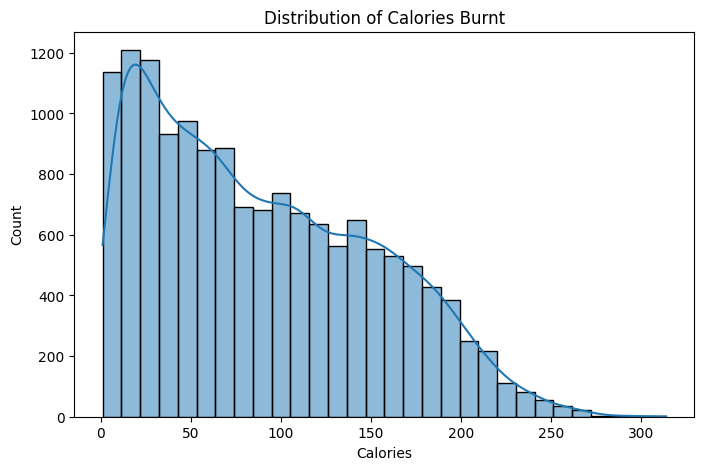

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,5))
sns.histplot(df['Calories'], bins = 30, kde = True)
plt.title('Distribution of Calories Burnt')
plt.show()

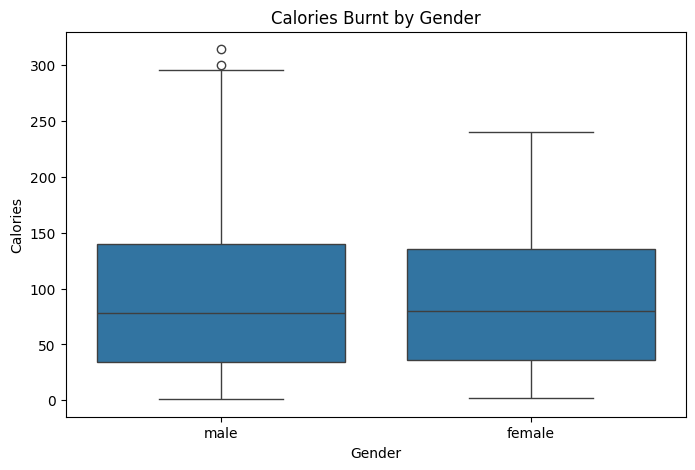

In [9]:
plt.figure(figsize = (8,5))
sns.boxplot(x='Gender',y='Calories',data = df)
plt.title('Calories Burnt by Gender')
plt.show()

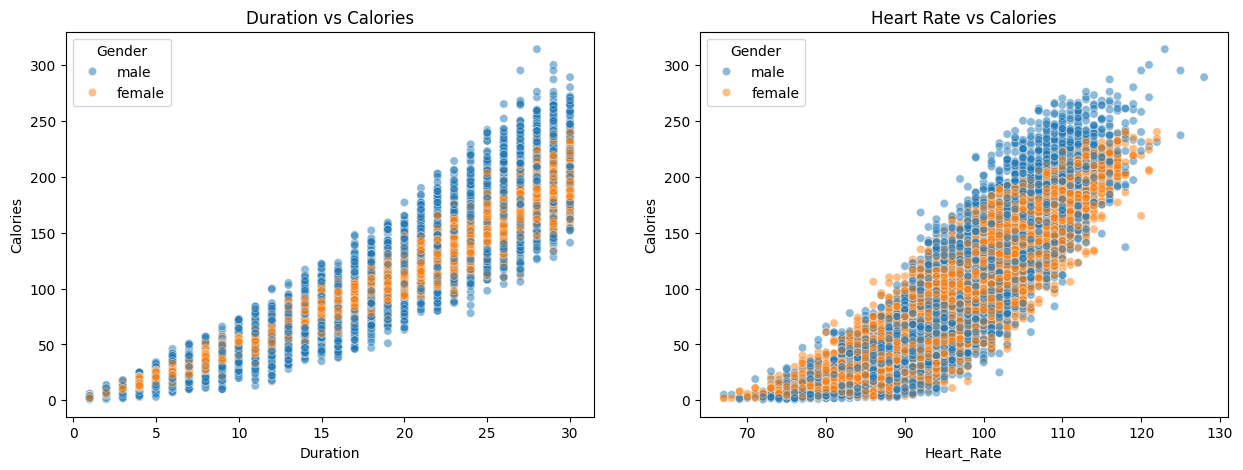

In [10]:
fig, axes = plt.subplots(1,2,figsize = (15,5))
sns.scatterplot(ax=axes[0], x=df['Duration'], y=df['Calories'],hue = df['Gender'],alpha = 0.5)
axes[0].set_title('Duration vs Calories')
sns.scatterplot(ax=axes[1], x=df['Heart_Rate'], y=df['Calories'],hue = df['Gender'],alpha = 0.5)
axes[1].set_title('Heart Rate vs Calories')
plt.show()

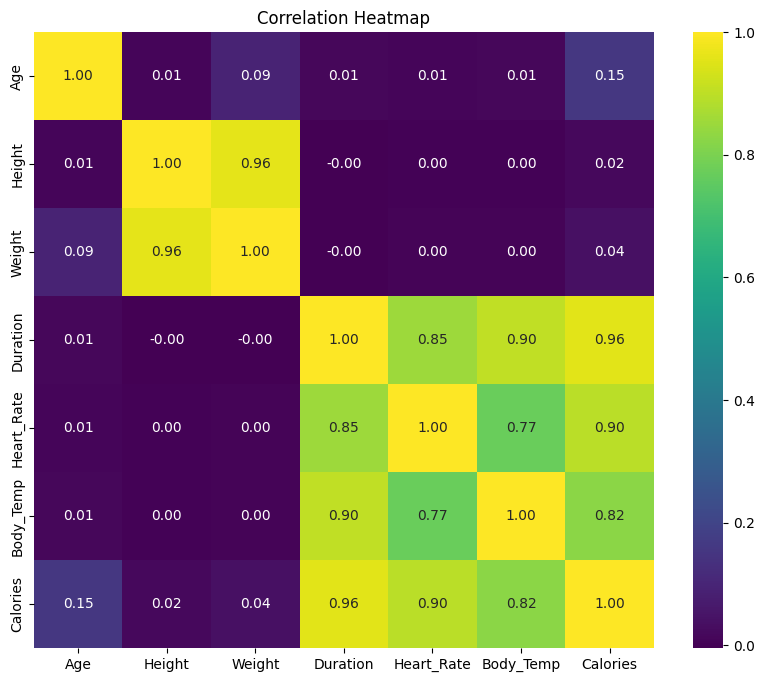

In [11]:
plt.figure(figsize=(10,8))

correlation_matrix = df.drop(columns=['Gender']).corr()

sns.heatmap(correlation_matrix, annot=True, cmap = 'viridis',fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [12]:
df['BMI'] = df['Weight']/((df['Height']/100)**2)
df['Total_Exertion'] = df['Duration']*df['Heart_Rate']
df['Temp_Spike'] = df['Body_Temp'] - 37.0

correlations = df.drop(columns='Gender').corr()['Calories'].sort_values(ascending = False)
print(correlations)

Calories          1.000000
Total_Exertion    0.974597
Duration          0.955421
Heart_Rate        0.897882
Body_Temp         0.824558
Temp_Spike        0.824558
Age               0.154395
BMI               0.056473
Weight            0.035481
Height            0.017537
Name: Calories, dtype: float64


In [13]:
columns_to_drop = ['Duration','Heart_Rate','Height','Weight']
df_clean = df.drop(columns = columns_to_drop,errors='ignore')

df_clean = pd.get_dummies(df_clean, columns=['Gender'], drop_first = True,dtype= 'int')
df_clean.head()

,Age,Body_Temp,Calories,BMI,Total_Exertion,Temp_Spike,Gender_male
0,68,40.8,231.0,26.038781,3045.0,3.8,1
1,20,40.3,66.0,21.773842,1316.0,3.3,0
2,69,38.7,26.0,24.655910,440.0,1.7,1
3,34,40.5,71.0,22.159109,1300.0,3.5,0
4,27,39.8,35.0,24.456063,810.0,2.8,0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

X = df_clean.drop(columns=['Calories'])
y = df_clean['Calories']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

y_train_log = np.log1p(y_train)

lr_untransformed = LinearRegression()
lr_transformed = LinearRegression()
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
xgb = XGBRegressor()

lr_untransformed.fit(X_train,y_train)
lr_transformed.fit(X_train,y_train_log)

rf.fit(X_train,y_train)

xgb.fit(X_train,y_train)

pred_lr_raw = lr_untransformed.predict(X_test)
pred_lr_log = lr_transformed.predict(X_test)
pred_rf = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)

pred_lr_log_real = np.expm1(pred_lr_log)

results = pd.DataFrame({
    'Model': ['Linear Regression (Raw Target)', 'Linear Regression (Log Transformed Target)','Random Forest','XGBoost Regressor'],
    'RMSE': [
        root_mean_squared_error(y_test,pred_lr_raw),
        root_mean_squared_error(y_test,pred_lr_log_real),
        root_mean_squared_error(y_test,pred_rf),
        root_mean_squared_error(y_test,pred_xgb)
    ],
    'R² Score': [
        r2_score(y_test, pred_lr_raw),
        r2_score(y_test, pred_lr_log_real),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb)
    ]
})

print(results.to_markdown(index=False))

| Model                                      |     RMSE |   R² Score |
|:-------------------------------------------|---------:|-----------:|
| Linear Regression (Raw Target)             | 10.1149  |   0.974649 |
| Linear Regression (Log Transformed Target) | 23.4221  |   0.864068 |
| Random Forest                              |  6.05146 |   0.990926 |
| XGBoost Regressor                          |  5.9904  |   0.991108 |
